##### Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

##### Load the datasets

In [2]:
general_b = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\TimeSeries\General_Medicine_Ward_B_TimeSeries.csv")


In [3]:
general_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hospital_id     3655 non-null   object 
 1   datetime        3655 non-null   object 
 2   ward            3655 non-null   object 
 3   occupied_beds   3655 non-null   float64
 4   staffed_beds    3655 non-null   float64
 5   occupancy_rate  3655 non-null   float64
dtypes: float64(3), object(3)
memory usage: 171.5+ KB


- Run the ADF test for every hospital

In [4]:
general_b["hospital_id"].unique()

array(['HHN-BIR-01', 'HHN-EDI-01', 'HHN-LON-01', 'HHN-LON-02',
       'HHN-MAN-01'], dtype=object)

In [5]:
results = []

for hospital in general_b["hospital_id"].unique():
    hospital_data = (general_b[general_b["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    adf = adfuller(hospital_data["occupied_beds"])
    results.append({"Hospital": hospital, "ADF Statistic": round(adf[0],4), "p-value": round(adf[1],4), 
                    "Stationary": "Yes" if adf[1] < 0.05 else "No"})

adf_results = pd.DataFrame(results)

print(f"ADF Test Results for General Medicine Ward B Unit Occupied Beds")
adf_results

ADF Test Results for General Medicine Ward B Unit Occupied Beds


,Hospital,ADF Statistic,p-value,Stationary
0,HHN-BIR-01,-3.1630,0.0222,Yes
1,HHN-EDI-01,-5.8569,0.0000,Yes
2,HHN-LON-01,-4.3794,0.0003,Yes
3,HHN-LON-02,-6.2842,0.0000,Yes
4,HHN-MAN-01,-2.4411,0.1305,No


       Four hospitals (Birmingham, Edinburgh, London 1, and London 2) showed stable bed occupancy, meaning demand stayed around a normal level over time.
       Manchester was the only hospital that was not stable, with bed occupancy showing a long-term trend.
       The changing trend in Manchester may be caused by increased patient demand, delayed discharges, or longer hospital stays.
       Unlike General Medicine Ward A, where London 1 was the outlier, Manchester is the only outlier in Ward B.
       The four stable hospitals can use a SARIMA model with d = 0 (no differencing).
       Manchester requires d = 1 (first differencing) to remove the trend before forecasting.
       These findings show that forecasting models should be tailored to individual hospitals, as bed occupancy patterns differ across locations.

- Autocorrelation (ACF) for all hospitals

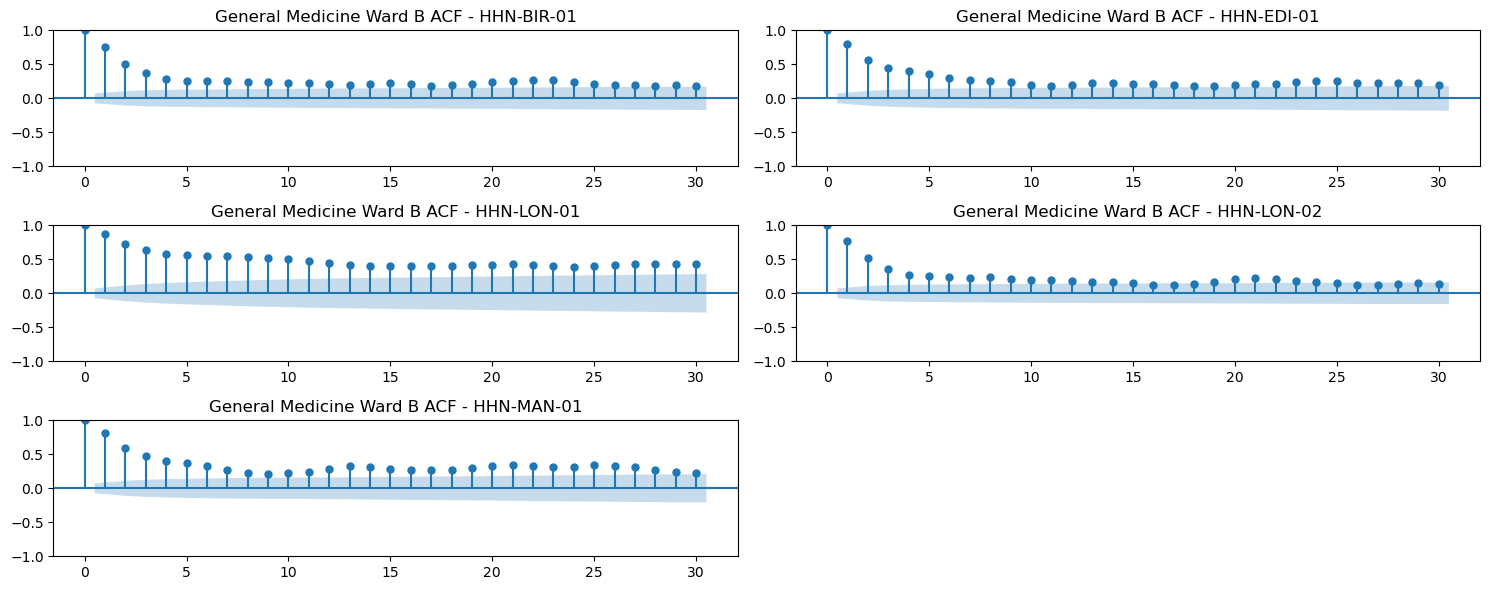

In [6]:
# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 6))
axes = axes.flatten()

# Loop through hospitals
for i, hospital in enumerate(sorted(general_b["hospital_id"].unique())):

    hospital_data = (general_b[general_b["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_acf(hospital_data["occupied_beds"], lags=30,ax=axes[i])
    axes[i].set_title(f"General Medicine Ward B ACF - {hospital}")

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

     Manchester showed a strong long-term occupancy pattern that did not fade over time, confirming it is non-stationary.
     London 1 also showed a long memory pattern, meaning beds tend to stay occupied for longer periods, although it remains statistically stable.
     Birmingham and London 2 showed faster occupancy decay, indicating quicker patient turnover and more stable demand.
     There was little evidence of a strong weekly pattern, suggesting bed occupancy is mainly driven by emergency and acute admissions rather than scheduled weekly activities.
     Manchester should be modelled with differencing (d = 1) to remove the long-term trend before forecasting.
     The other hospitals can use standard models with d = 0 because their occupancy is generally stable.
     Overall, recent patient admissions and discharges are more important for forecasting than long-term historical data, except for Manchester where the underlying trend must first be corrected.


- PACF for all hospitals

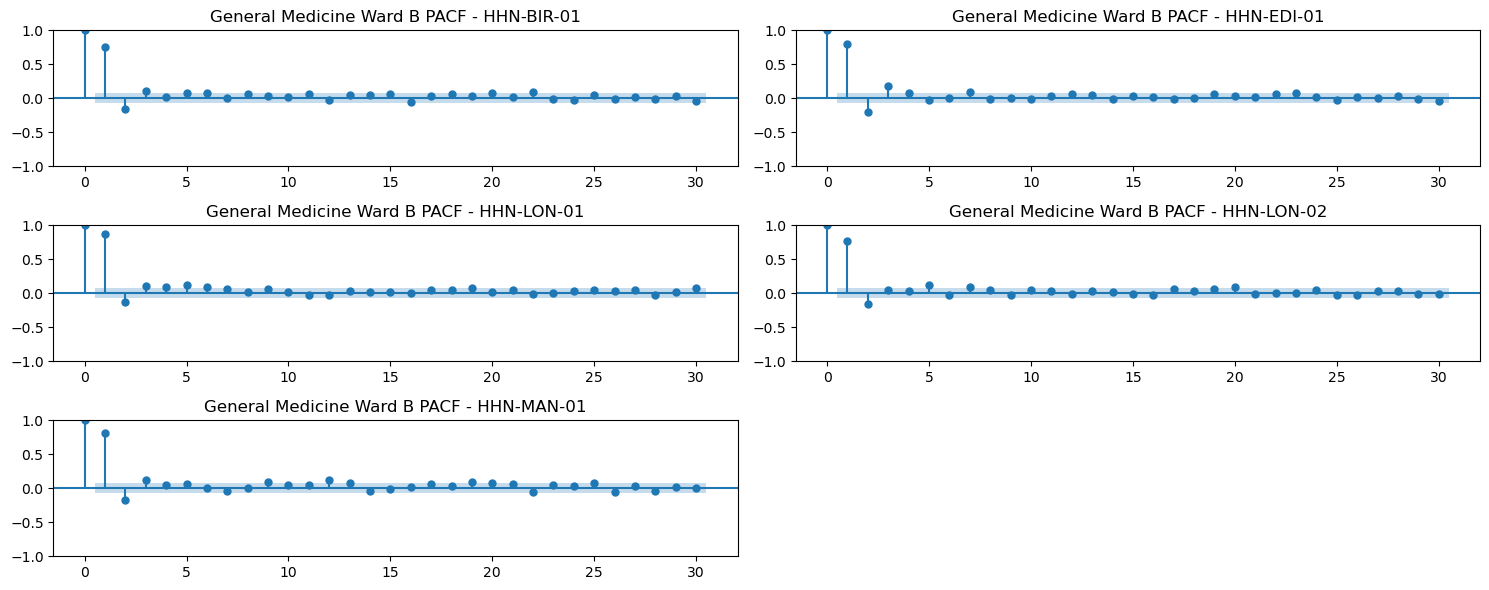

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(15, 6))
axes = axes.flatten()

for i, hospital in enumerate(sorted(general_b["hospital_id"].unique())):

    hospital_data = (general_b[general_b["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_pacf(hospital_data["occupied_beds"], lags=30, ax=axes[i], method="ywm")
    axes[i].set_title(f"General Medicine Ward B PACF - {hospital}")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

     All five hospitals showed a similar **2-day occupancy pattern**, indicating consistent short-term behaviour.
     Yesterday's bed occupancy (Lag 1) had the strongest effect on today's occupancy.
     Occupancy from two days ago (Lag 2) had a negative effect, showing that many patients are discharged or transferred after 1–2 days.
     After the first two days, older occupancy data had **very little influence** on future bed demand.
     The results indicate that a 2-day memory (p = 2) is sufficient for forecasting General Medicine Ward B occupancy.
     Manchester requires differencing (d = 1)** because of its long-term trend, while the other hospitals can use **d = 0** as their data is already stable.


- Seasonal Decomposition for all hospitals

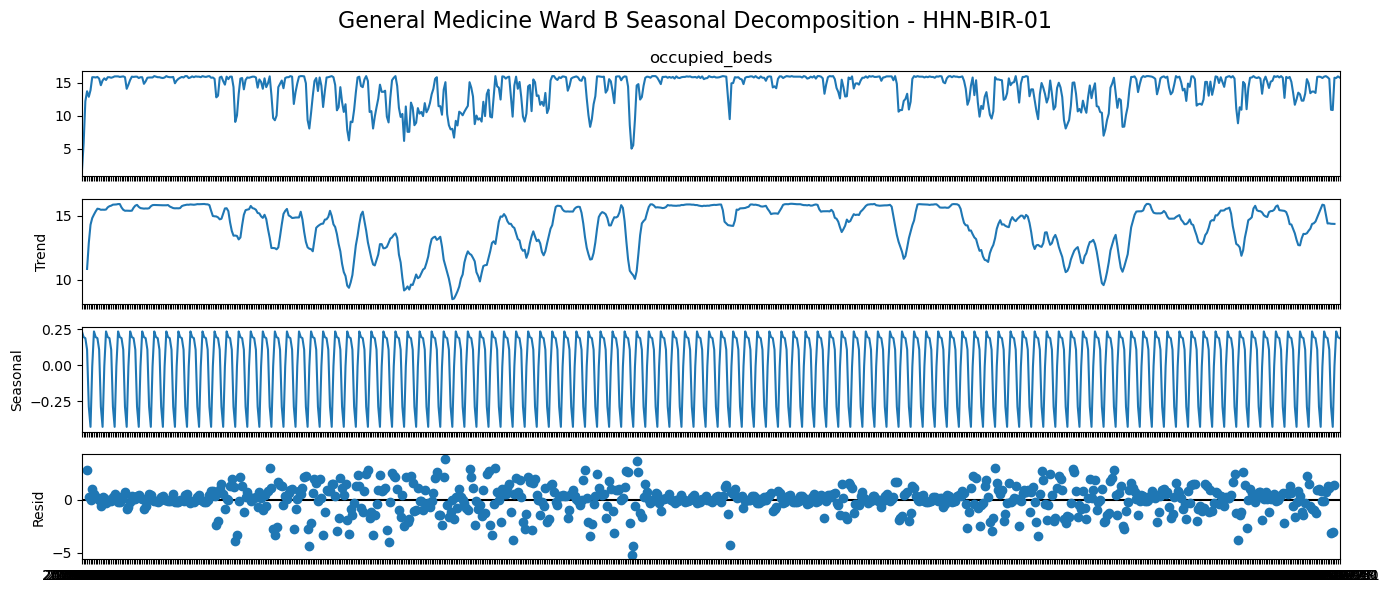

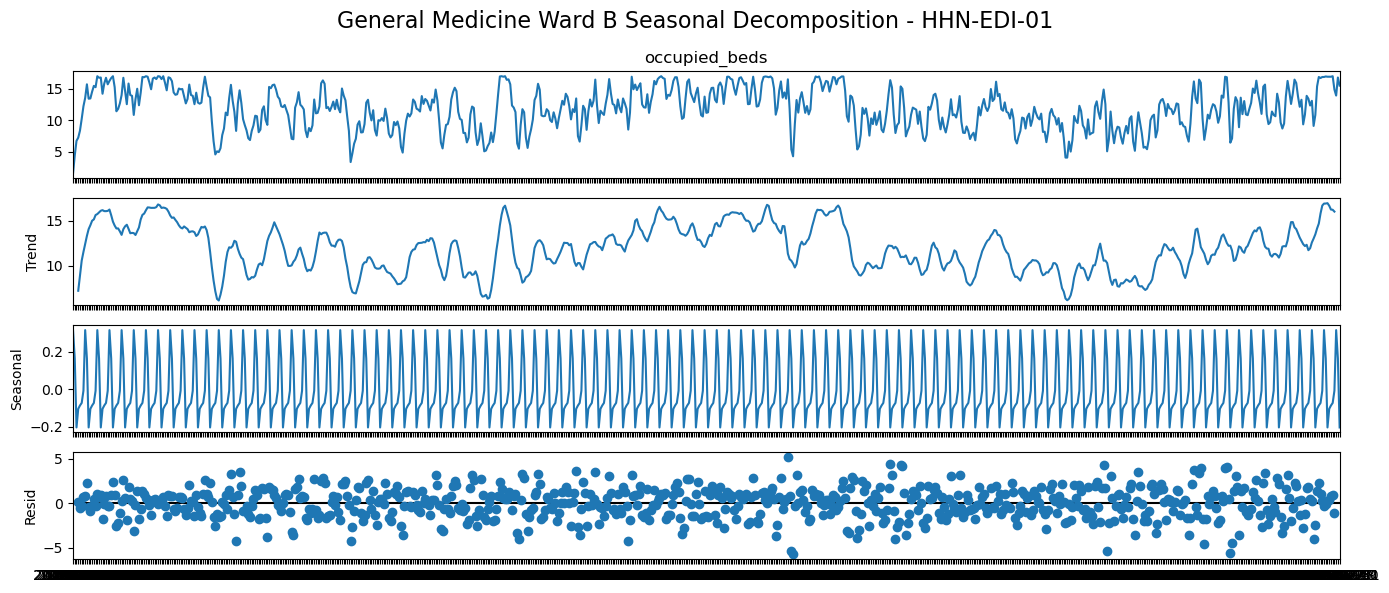

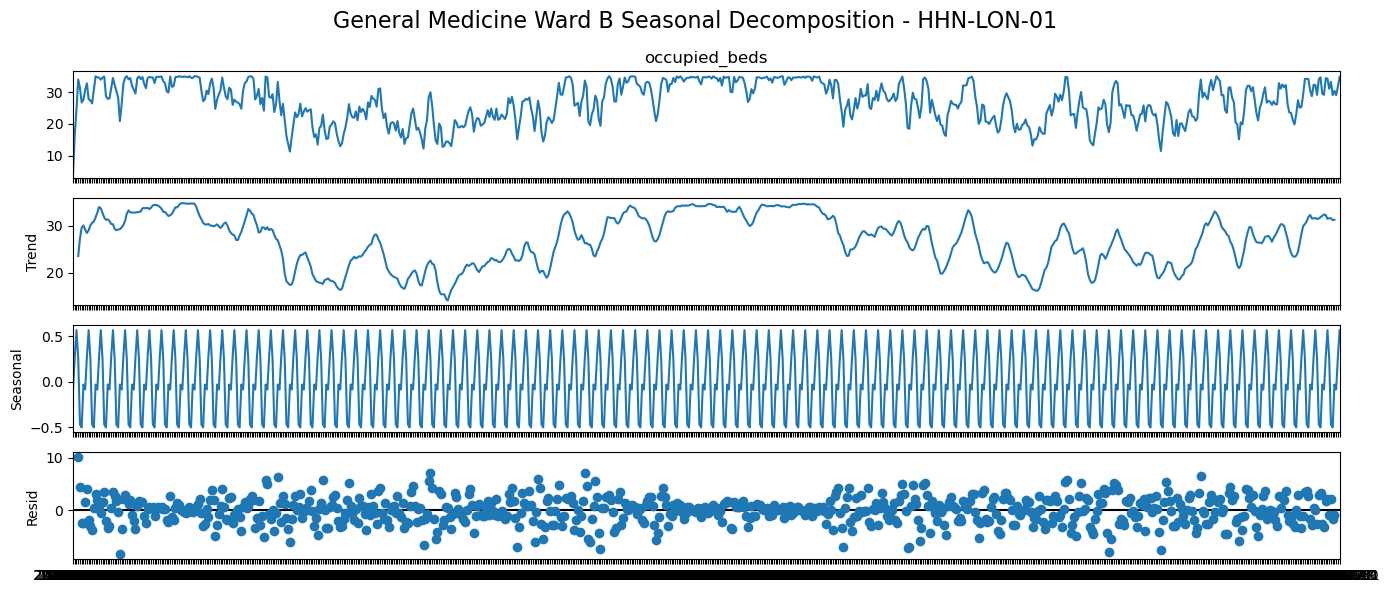

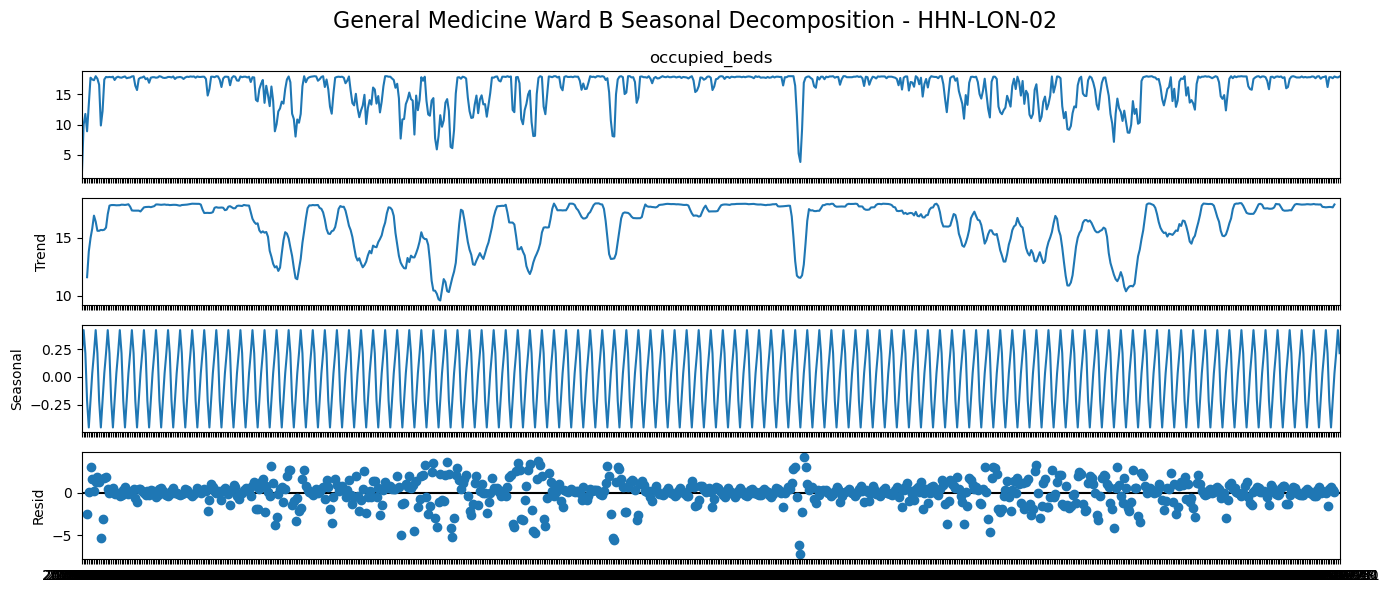

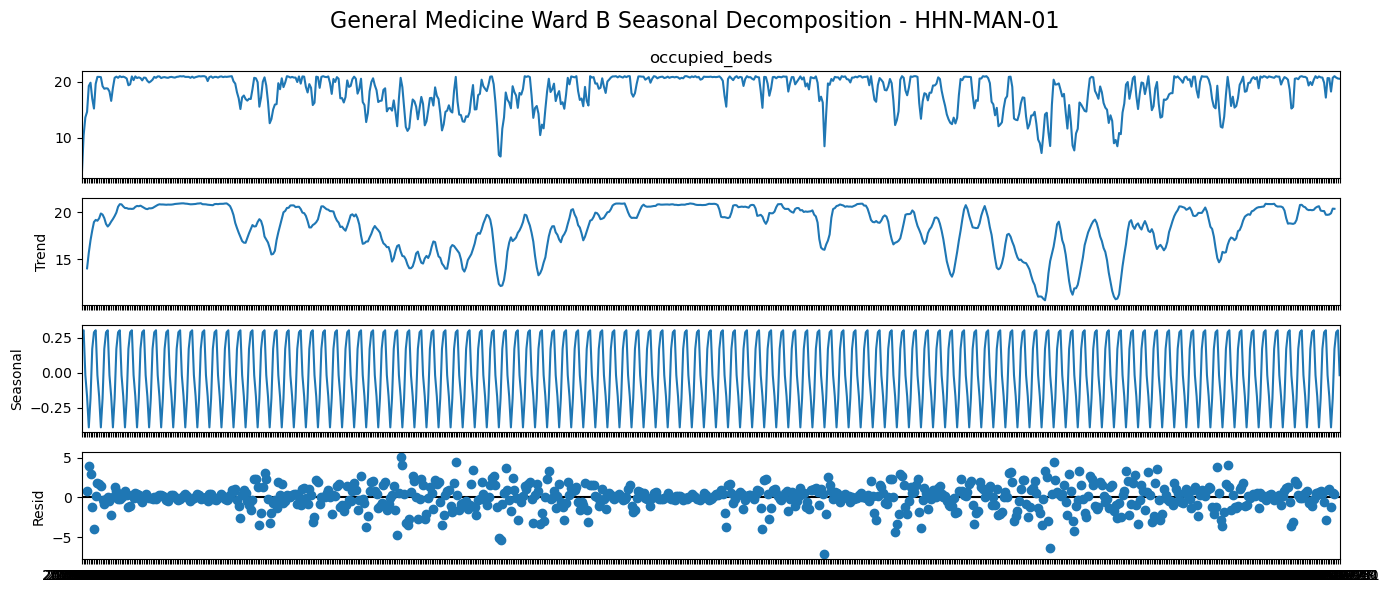

In [8]:
for hospital in sorted(general_b["hospital_id"].unique()):

    hospital_data = (general_b[general_b["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    fig = result.plot()
    fig.set_size_inches(14,6)
    fig.suptitle(f"General Medicine Ward B Seasonal Decomposition - {hospital}", fontsize=16)
    plt.tight_layout()
    plt.show()

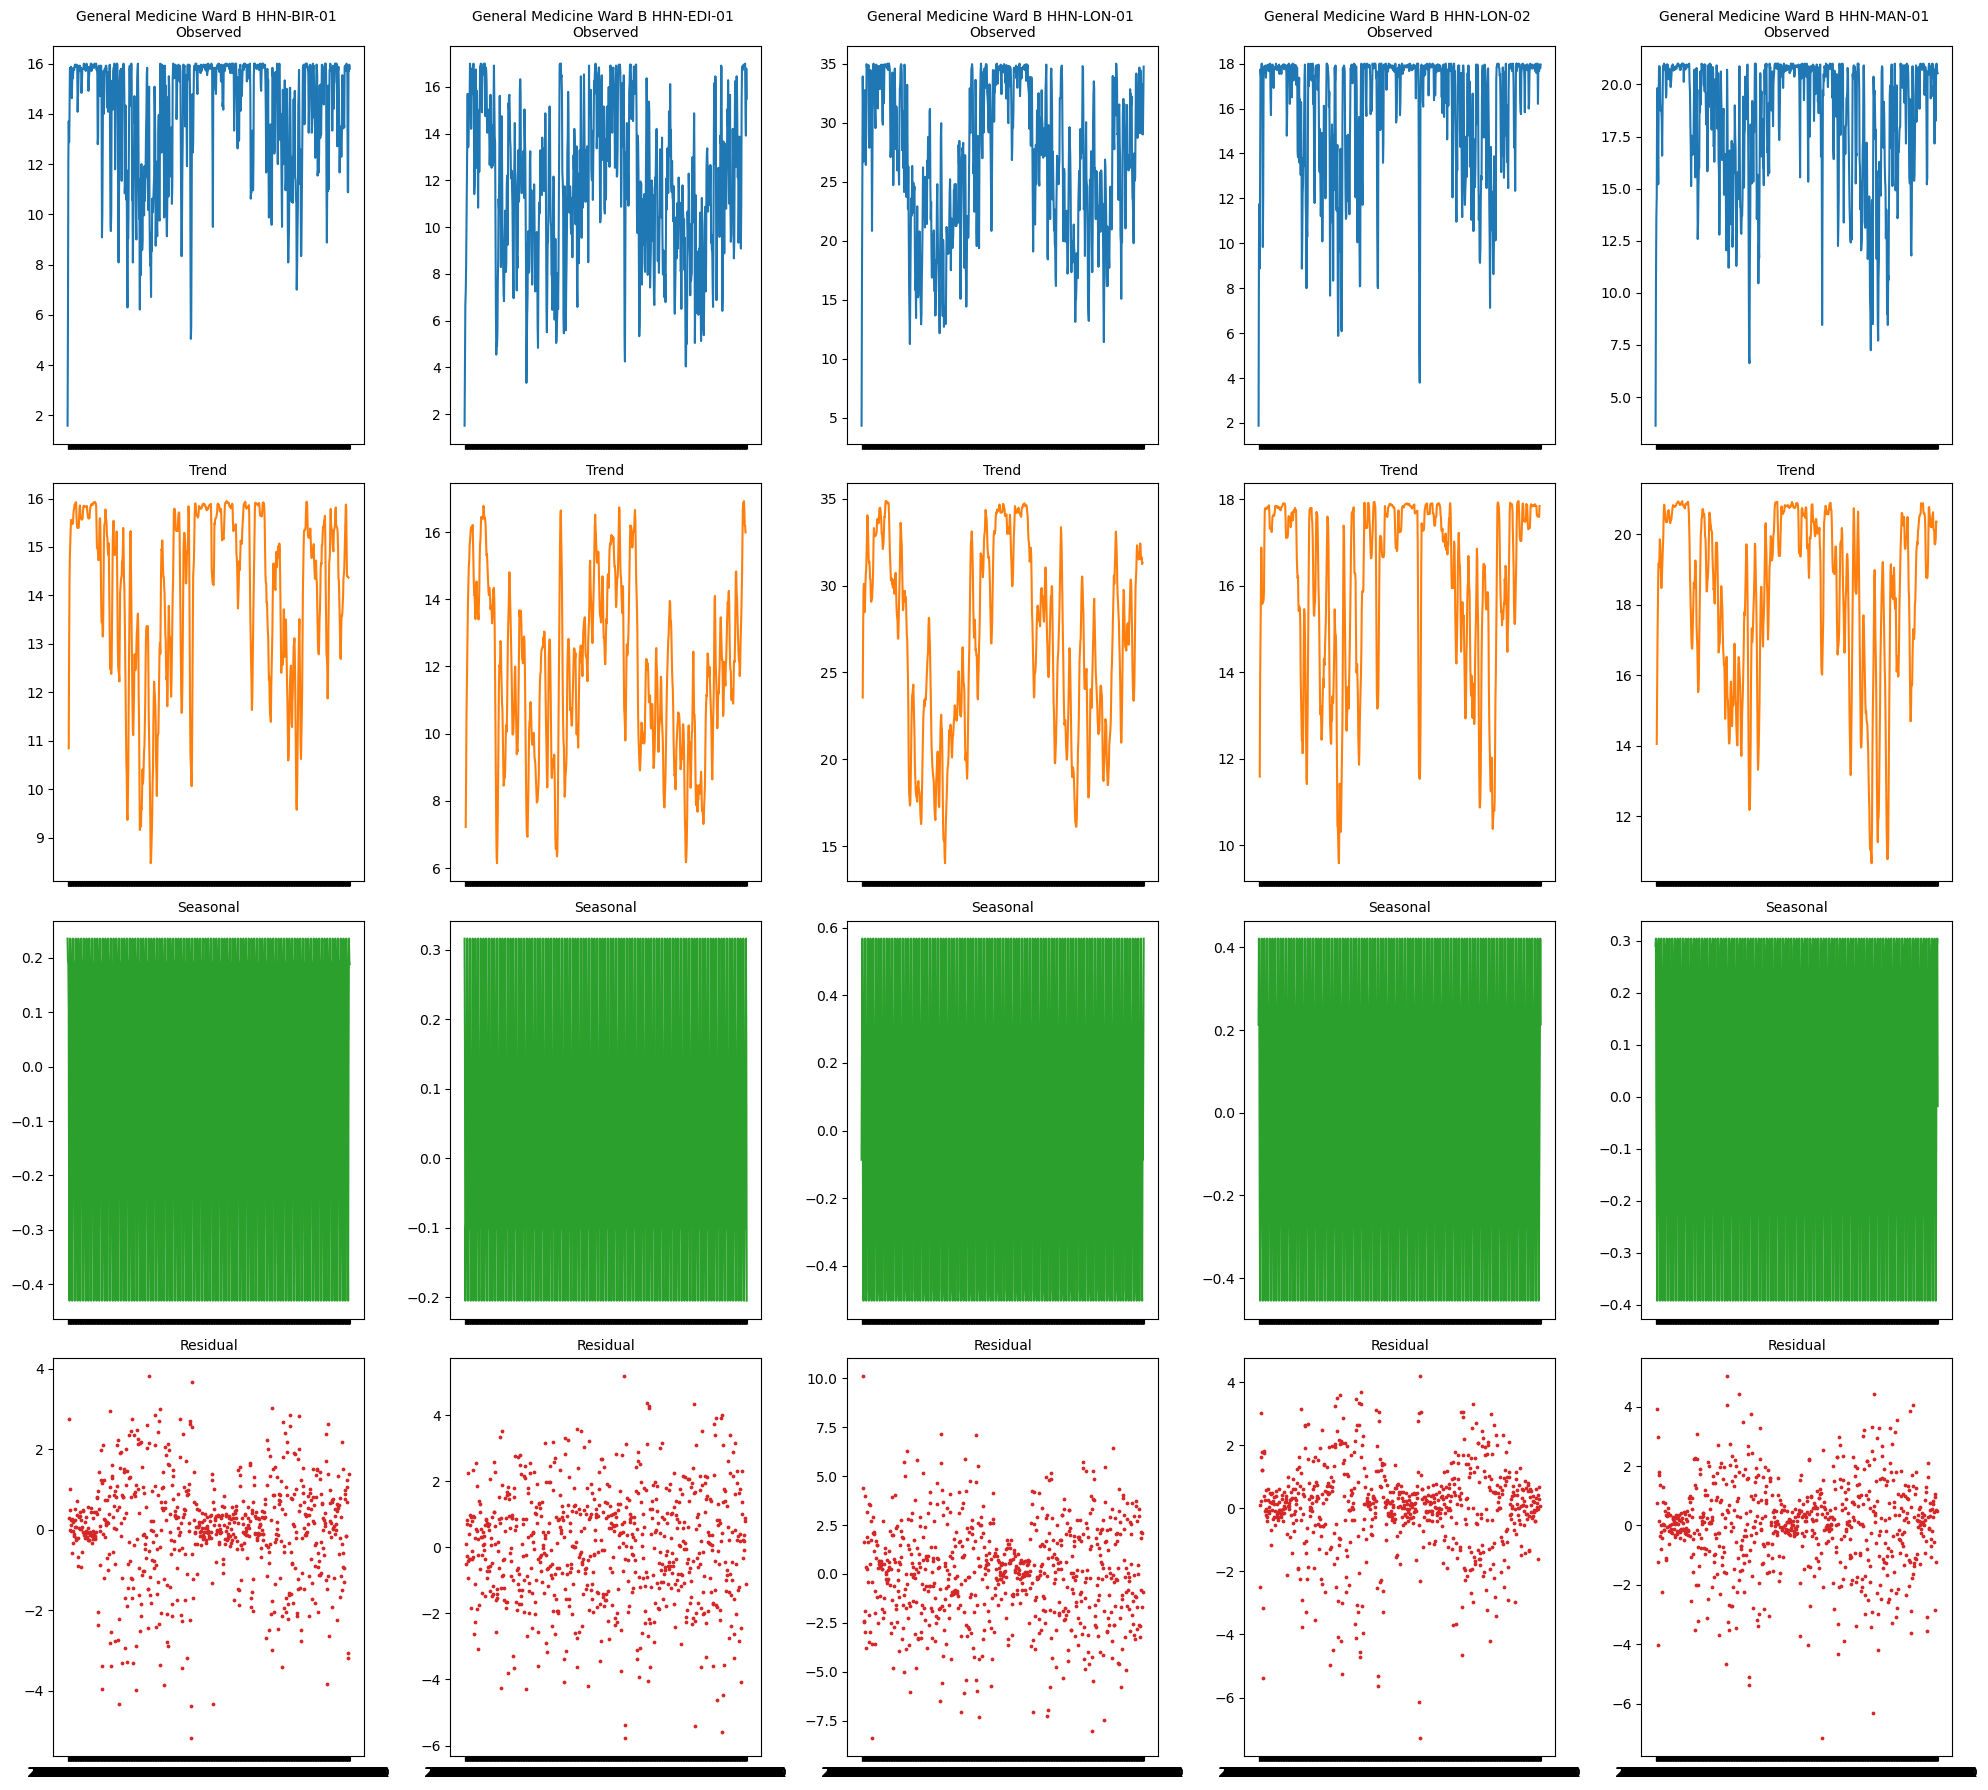

In [9]:
# Create a grid: 4 rows (Observed/Trend/Season/Resid) by X columns (one per hospital)
fig, axes = plt.subplots(4, 5, figsize=(20, 18), sharex=True)

hospitals = sorted(general_b["hospital_id"].unique())
for col_idx, hospital in enumerate(hospitals):
    # Filter and decompose data
    hospital_data = general_b[general_b["hospital_id"] == hospital].sort_values("datetime").set_index("datetime")
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    
    # Manually plot each layer into its specific column cell
    axes[0, col_idx].plot(result.observed, color='tab:blue')
    axes[0, col_idx].set_title(f"General Medicine Ward B {hospital} \nObserved", fontsize=10)
    
    axes[1, col_idx].plot(result.trend, color='tab:orange')
    axes[1, col_idx].set_title("Trend", fontsize=10)
    
    axes[2, col_idx].plot(result.seasonal, color='tab:green')
    axes[2, col_idx].set_title("Seasonal", fontsize=10)
    
    axes[3, col_idx].scatter(result.resid.index, result.resid, color='tab:red', s=3)
    axes[3, col_idx].set_title("Residual", fontsize=10)

plt.tight_layout()
plt.show()


     Manchester showed an unstable long-term trend, confirming the earlier ADF and ACF results that it is non-stationary.
     Weekly seasonal patterns were very small, indicating that bed occupancy is mainly driven by emergency admissions rather than weekly schedules.
     Most of the remaining variation was due to random day-to-day changes, but these were reduced when wards reached full capacity.
     Manchester requires differencing (d = 1) for forecasting, while the other hospitals can use d = 0 because their occupancy is stable.
     Forecasts should include bed capacity limits to prevent predicting more occupied beds than are physically available.
     Overall, General Medicine Ward B is mainly influenced by emergency demand, patient length of stay, and limited bed capacity, rather than regular weekly patterns.